In [20]:
import pandas as pd
import numpy as np
import ccxt
import ta

import os
import time

from ta.volume import VolumeWeightedAveragePrice, MFIIndicator, chaikin_money_flow, OnBalanceVolumeIndicator
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from ta.volatility import BollingerBands
from ta.trend import MACD

from scipy.stats import trim_mean
from scipy.interpolate import make_smoothing_spline

import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [5]:

def fetch_bitcoin_data(symbol="BTC/USDT", timeframe="5m", start_date='2024-01-01 00:00:00', end_date='2024-01-10 00:00:00', limit=500):
    exchange = ccxt.binance()
    
    since = exchange.parse8601(start_date)
    end_ts = exchange.parse8601(end_date)
    
    all_ohlcv = []

    while since < end_ts:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit)
        
        if not ohlcv:
            break
        
        all_ohlcv.extend(ohlcv)
        
        last_ts = ohlcv[-1][0]

        if last_ts == since:
            break
        
        since = last_ts + 1

        time.sleep(exchange.rateLimit / 1000)

    filtered = [candle for candle in all_ohlcv if candle[0] <= end_ts]
    
    return filtered

In [6]:
def get_binance_data(symbol="BTC/USDT", timeframe="5m", start_date='2024-01-01 00:00:00', end_date='2024-01-10 00:00:00'):

    ohlcv = fetch_bitcoin_data(symbol='BTC/USDT', timeframe=timeframe, start_date=start_date, end_date=end_date)

    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

    # === INDICADORES ===
    df['BB'] = BollingerBands(close=df['close']).bollinger_pband()
    
    df['rsi'] = RSIIndicator(close=df['close'], window=14).rsi()

    df['macd'] = MACD(close=df['close']).macd()

    df['obv'] = OnBalanceVolumeIndicator( df['close'],  df['volume']).on_balance_volume()

    df['atr'] = AverageTrueRange( df['high'], df['low'], df['close']).average_true_range()

    df['mfi'] = MFIIndicator(
        high=df['high'],
        low=df['low'],
        close=df['close'],
        volume=df['volume'],
        window=14
    ).money_flow_index()

    df['cmf'] = chaikin_money_flow(
        df['high'], df['low'], df['close'], df['volume'], window=20
    )

    # VWAP
    typical_price = (df['high'] + df['low'] + df['close']) / 3
    df['vwap'] = (df['volume'] * typical_price).cumsum() / df['volume'].cumsum()

    # Media y desviación rolling
    vol_mean = df['volume'].rolling(window=20).mean()
    vol_std = df['volume'].rolling(window=20).std()

    # Z-score del volumen (clave)
    df['vol_zscore'] = (df['volume'] - vol_mean) / vol_std

    # Clasificación tipo "heatmap"
    df['vol_level'] = pd.cut(
        df['vol_zscore'],
        bins=[-np.inf, -1, 1, 2, np.inf],
        labels=["low", "normal", "high", "extreme"]
    )

    # Flag de anomalía (para decisiones rápidas)
    df['vol_anomaly'] = df['vol_zscore'] > 2

    # Intensidad normalizada (0 a 1) útil para modelos
    df['vol_intensity'] = (df['vol_zscore'] - df['vol_zscore'].min()) / (
        df['vol_zscore'].max() - df['vol_zscore'].min()
    )

    df['candle_type'] = np.where(
        df['close'] > df['open'], 1,
        np.where(df['close'] < df['open'], -1, 0)
    )
    
    # Rolling de 7 velas
    df['candle_bias_7'] = df['candle_type'].rolling(window=7).sum()
    
    # Normalizamos a señal discreta
    df['candle_bias_7_signal'] = np.sign(df['candle_bias_7'])
    df['green_ratio_7'] = (
        (df['candle_type'] == 1)
        .rolling(window=7)
        .mean()
    )

    return df

In [7]:
df = get_binance_data(start_date='2026-01-01 00:00:00', end_date='2026-05-19 00:00:00')

In [17]:
df

,timestamp,open,high,low,close,volume,BB,rsi,macd,obv,atr,mfi,cmf,vwap,vol_zscore,vol_level,vol_anomaly,vol_intensity,candle_type,candle_bias_7,candle_bias_7_signal,green_ratio_7
0,2026-01-01 00:00:00,87648.21,87701.91,87632.74,87701.91,18.44460,NaN,NaN,NaN,18.44460,0.000000,NaN,NaN,87678.853333,NaN,NaN,False,NaN,1,NaN,NaN,NaN
1,2026-01-01 00:05:00,87701.91,87816.00,87701.90,87764.06,57.78717,NaN,NaN,NaN,76.23177,0.000000,NaN,NaN,87740.861476,NaN,NaN,False,NaN,1,NaN,NaN,NaN
2,2026-01-01 00:10:00,87764.06,87764.07,87742.61,87742.61,9.86578,NaN,NaN,NaN,66.36599,0.000000,NaN,NaN,87741.881526,NaN,NaN,False,NaN,-1,NaN,NaN,NaN
3,2026-01-01 00:15:00,87742.62,87760.19,87742.61,87760.19,9.47001,NaN,NaN,NaN,75.83600,0.000000,NaN,NaN,87743.115074,NaN,NaN,False,NaN,1,NaN,NaN,NaN
4,2026-01-01 00:20:00,87760.19,87774.00,87760.18,87773.97,4.62578,NaN,NaN,NaN,80.46178,0.000000,NaN,NaN,87744.327841,NaN,NaN,False,NaN,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39740,2026-05-18 23:40:00,77042.37,77118.54,77042.37,77118.54,23.30055,0.612650,56.525166,14.179569,-34921.23731,70.638631,43.042483,0.110600,74648.284211,-0.192280,normal,False,0.358081,1,-1.0,-1.0,0.428571
39741,2026-05-18 23:45:00,77118.54,77118.54,76995.00,77023.87,36.45940,0.238205,47.687322,9.579001,-34957.69671,74.417300,35.843961,0.064220,74648.315774,0.817389,normal,False,0.504073,-1,-1.0,-1.0,0.428571
39742,2026-05-18 23:50:00,77023.88,77023.88,76948.80,76972.68,19.39011,0.082254,43.707884,1.781872,-34977.08682,74.464636,35.818234,0.040227,74648.332111,-0.554035,normal,False,0.305773,-1,-1.0,-1.0,0.428571
39743,2026-05-18 23:55:00,76972.69,77014.31,76972.68,77001.87,16.86886,0.223344,46.451959,-2.018749,-34960.21796,72.119304,44.371824,0.036308,74648.346412,-0.678906,normal,False,0.287718,1,-1.0,-1.0,0.428571


In [10]:
df.to_csv("data/btc_hit_5min.csv", index=False)

[]

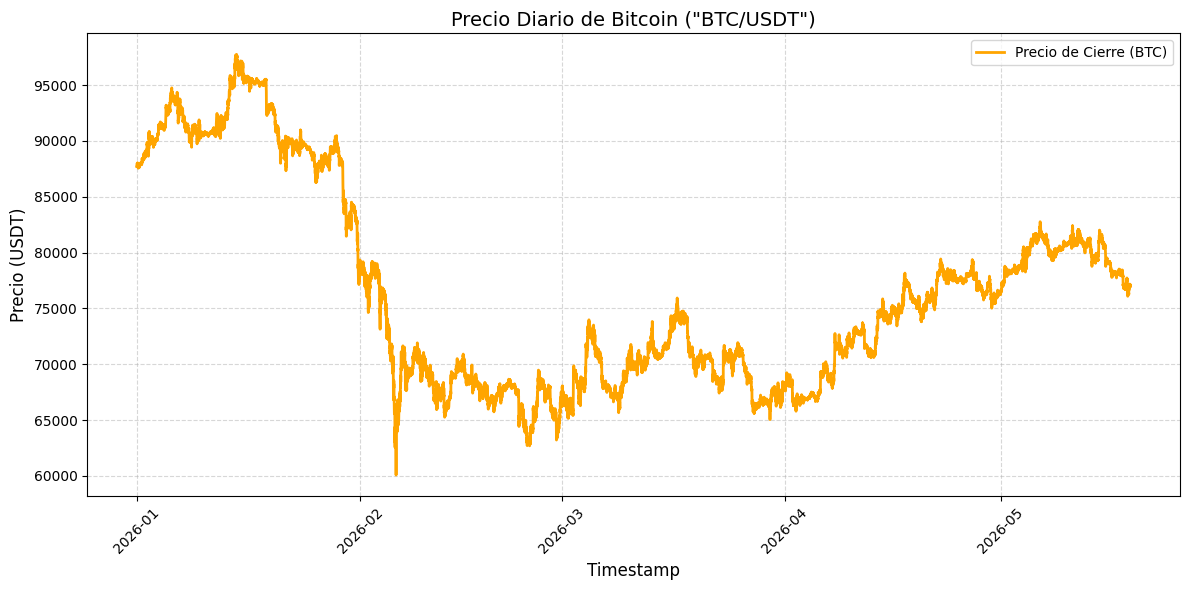

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['timestamp'], df['close'], label='Precio de Cierre (BTC)', color='orange', linewidth=2)

ax.set_title(f'Precio Diario de Bitcoin ("BTC/USDT")', fontsize=14)
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Precio (USDT)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.plot()

In [11]:
def plot_candles_volume(df, filename="plot.png"):
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={'height_ratios': [3, 1]}
    )

    for i in range(len(df)):
        open_ = df['open'].iloc[i]
        close_ = df['close'].iloc[i]
        high_ = df['high'].iloc[i]
        low_ = df['low'].iloc[i]

        color = 'green' if close_ > open_ else 'red'

        # Wick
        ax1.plot([i, i], [low_, high_])

        # Body
        ax1.add_patch(
            plt.Rectangle(
                (i - 0.3, min(open_, close_)),
                0.6,
                abs(close_ - open_),
            )
        )
        ax1.patches[-1].set_facecolor(color)

    ax1.set_title("Candles")

    vol = df['volume'].values
    intensity = df['vol_intensity'].values

    # Normalizamos intensidad para colormap
    norm = (intensity - np.nanmin(intensity)) / (np.nanmax(intensity) - np.nanmin(intensity))
    colors = plt.cm.RdYlGn(norm)

    ax2.bar(range(len(df)), vol, color=colors)

    vol_clean_mean = trim_mean(vol[~np.isnan(vol)], 0.1)
    
    ax2.axhline(
        y=vol_clean_mean,
        linestyle='--',
        label=f"Robust mean vol"
    )

    ax2.set_title("Volume")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(filename)
    plt.close()

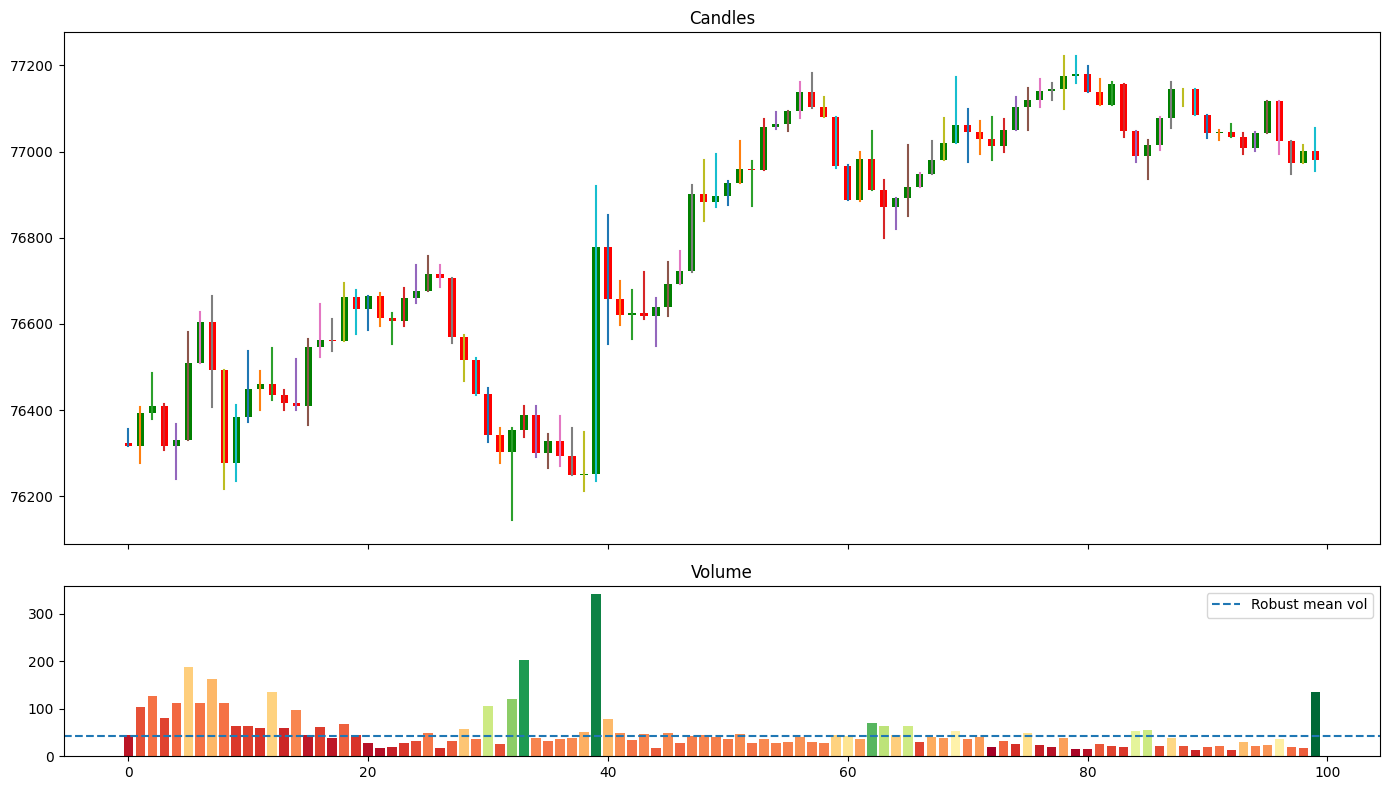

In [12]:
plot_candles_volume(df.iloc[-100:,:])

In [28]:
def calcular_derivada_spline(data: pd.DataFrame, lam: float = 10.0) -> pd.DataFrame:
    df = data.copy()
    col_cierre = 'close'
    
    x = np.arange(len(df))
    y = df[col_cierre].values
    
    spline_func = make_smoothing_spline(x, y, lam=lam)
    df['Spline_SM'] = spline_func(x)
    df['Spline_Derivative'] = spline_func.derivative()(x)
    
    return df

In [29]:
df = calcular_derivada_spline(df, lam=10.0)

[]

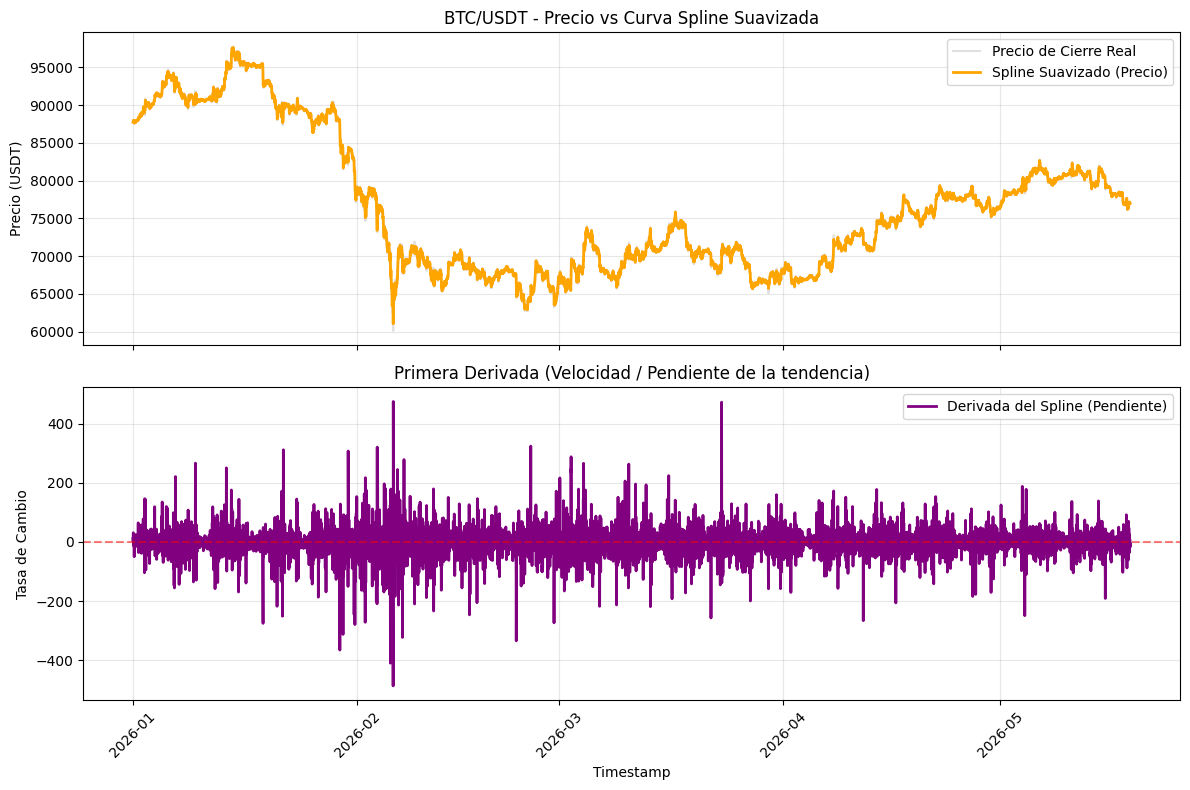

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df['timestamp'], df['close'], label='Precio de Cierre Real', color='lightgray', alpha=0.7)
ax1.plot(df['timestamp'], df['Spline_SM'], label='Spline Suavizado (Precio)', color='orange', linewidth=2)
ax1.set_title(f'BTC/USDT - Precio vs Curva Spline Suavizada')
ax1.set_ylabel('Precio (USDT)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df['timestamp'], df['Spline_Derivative'], label='Derivada del Spline (Pendiente)', color='purple', linewidth=2)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5) 
ax2.set_title('Primera Derivada (Velocidad / Pendiente de la tendencia)')
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Tasa de Cambio')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.plot()

In [31]:
df[['timestamp', 'close', 'Spline_SM', 'Spline_Derivative']]

,timestamp,close,Spline_SM,Spline_Derivative
0,2026-01-01 00:00:00,87701.91,87726.973206,11.321500
1,2026-01-01 00:05:00,87764.06,87737.876986,10.068340
2,2026-01-01 00:10:00,87742.61,87746.710828,7.618010
3,2026-01-01 00:15:00,87760.19,87753.081984,5.074619
4,2026-01-01 00:20:00,87773.97,87756.879166,2.588527
...,...,...,...,...
39740,2026-05-18 23:40:00,77118.54,77036.518843,-8.200019
39741,2026-05-18 23:45:00,77023.87,77025.534329,-13.164109
39742,2026-05-18 23:50:00,76972.68,77011.372686,-14.582016
39743,2026-05-18 23:55:00,77001.87,76996.879741,-14.471589


## Filtro de eventos CUSUM para el ambiente de trading

El filtro **CUSUM** (*Cumulative Sum*) se usa como una etapa de preprocesamiento para detectar momentos en los que el precio acumuló un movimiento suficientemente grande frente a un umbral.

En este notebook conviene usarlo como **feature adicional** del ambiente, no necesariamente como filtro para borrar filas. Si eliminamos las velas que no son evento, el ambiente deja de avanzar en una línea temporal continua y los `step()` representan saltos entre eventos. Para Reinforcement Learning suele ser más estable conservar toda la serie y agregar una columna binaria `cusum_event` que indique cuándo ocurrió un evento.

Interpretación:

- `cusum_event = 1`: el precio acumuló un movimiento relevante y puede ser un momento interesante para abrir, cerrar o ajustar una posición.
- `cusum_event = 0`: no hubo un cambio acumulado suficiente según el umbral definido.

En datos reales, el umbral recomendado puede ser dinámico, por ejemplo `0.5 * ATR`, para que el filtro se adapte a la volatilidad del mercado.

In [47]:
def cusum_filter(close, threshold = 1.0):
    """
    Detecta eventos de mercado usando un filtro CUSUM simétrico.

    Parámetros
    ----------
    close : array-like
        Serie de precios de cierre. En este ambiente puede ser el vector `prices`.

    threshold : float o array-like
        Umbral mínimo de movimiento acumulado requerido para disparar un evento.
        - Si es float, se usa el mismo umbral en toda la serie.
        - Si es array-like, permite usar un umbral dinámico, por ejemplo 0.5 * ATR.

    Retorna
    -------
    np.ndarray
        Índices donde ocurrió un evento CUSUM.

    Cómo interpretarlo
    ------------------
    El filtro acumula cambios positivos y negativos del precio:
    - Si la suma positiva supera `threshold`, registra un evento alcista.
    - Si la suma negativa cae por debajo de `-threshold`, registra un evento bajista.

    El evento no es una señal directa de compra o venta. Solo indica que hubo
    suficiente movimiento acumulado para que el agente lo considere dentro de
    su observación o lógica de decisión.
    """
    close = np.asarray(close, dtype=np.float64)

    if close.ndim != 1:
        raise ValueError("close debe ser un vector unidimensional de precios")

    if np.isscalar(threshold):
        threshold_values = np.full(close.shape, float(threshold), dtype=np.float64)
    else:
        threshold_values = np.asarray(threshold, dtype=np.float64)
        if threshold_values.shape[0] != close.shape[0]:
            raise ValueError("threshold debe ser escalar o tener la misma longitud que close")

    t_events = []
    s_pos, s_neg = 0.0, 0.0
    price_diff = np.diff(close, prepend=np.nan)

    for i in range(1, len(close)):
        th = threshold_values[i]

        # Saltamos observaciones no válidas o umbrales no positivos.
        if np.isnan(th) or th <= 0 or np.isnan(price_diff[i]):
            continue

        # Acumulador de movimientos positivos y negativos.
        s_pos = max(0.0, s_pos + price_diff[i])
        s_neg = min(0.0, s_neg + price_diff[i])

        # Si se supera el umbral positivo o negativo, registramos evento
        # y reseteamos el acumulador correspondiente.
        if s_pos > th:
            s_pos = 0.0
            t_events.append(i)
        elif s_neg < -th:
            s_neg = 0.0
            t_events.append(i)

    return np.asarray(t_events, dtype=np.int64)

In [57]:
x = cusum_filter(df['atr'].values).astype(int)
x

array([   13,    14,    15, ..., 39741, 39743, 39744])

In [60]:
df['cusum_filter_atr'] = 0
df.loc[x, ['cusum_filter_atr']] = 1

In [65]:
cols = [c for c in df.columns if c not in ['open', 'high', 'low']]

In [68]:
df = df.dropna()
df.reset_index(drop=True, inplace=True)

In [69]:
df

,timestamp,open,high,low,close,volume,BB,rsi,macd,obv,atr,mfi,cmf,vwap,vol_zscore,vol_level,vol_anomaly,vol_intensity,candle_type,candle_bias_7,candle_bias_7_signal,green_ratio_7,Spline_Derivative,Spline_SM,cusum_filter,cusum_filter_atr
0,2026-01-01 02:05:00,87950.52,88025.18,87950.51,88025.18,7.74870,0.906049,67.960603,58.137226,103.46945,53.333624,61.121466,-0.017059,87859.649035,-1.020038,low,False,0.238392,1,1.0,1.0,0.571429,7.831239,87985.452572,26.0,1
1,2026-01-01 02:10:00,88025.18,88025.19,87986.00,87990.52,5.80521,0.779952,62.925874,58.580704,97.66424,52.323365,59.291589,0.051693,87861.254479,-1.071313,low,False,0.230978,-1,1.0,1.0,0.571429,2.390002,87990.468616,27.0,1
2,2026-01-01 02:15:00,87990.52,88088.10,87990.52,88001.11,42.65855,0.790873,63.808105,59.105358,140.32279,55.555982,59.595455,-0.037414,87874.025441,1.761830,high,False,0.640633,1,1.0,1.0,0.571429,-1.913750,87990.611737,28.0,1
3,2026-01-01 02:20:00,88001.12,88023.27,87966.70,87966.71,12.58654,0.662688,58.904589,56.098687,127.73625,55.628411,48.072700,-0.056194,87876.510946,-0.593153,normal,False,0.300117,-1,-1.0,-1.0,0.428571,-4.552534,87987.196105,29.0,0
4,2026-01-01 02:25:00,87966.72,87966.72,87939.68,87957.63,10.81146,0.610120,57.645350,52.379401,116.92479,53.586382,53.130670,-0.072463,87877.979078,-0.736750,normal,False,0.279354,-1,-3.0,-1.0,0.285714,-6.025743,87981.895194,30.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39278,2026-05-17 11:15:00,78357.58,78380.58,78315.33,78334.67,24.66308,0.395106,49.620051,57.165585,-32320.45376,66.132100,37.732013,0.005617,74627.461537,-0.345143,normal,False,0.335978,-1,-3.0,-1.0,0.285714,-9.153444,78373.409807,39740.0,0
39279,2026-05-17 11:20:00,78334.67,78367.49,78308.61,78367.48,7.20655,0.430463,52.904146,50.383126,-32313.24721,65.614093,27.146239,0.013654,74627.471302,-0.831463,normal,False,0.265659,1,-1.0,-1.0,0.428571,-2.340076,78367.781382,39741.0,0
39280,2026-05-17 11:25:00,78367.48,78377.05,78335.99,78350.04,17.48113,0.327661,51.001044,43.103841,-32330.72834,63.860229,41.374263,-0.003228,74627.495032,-0.565233,normal,False,0.304154,-1,-1.0,-1.0,0.428571,3.038200,78368.251291,39742.0,1
39281,2026-05-17 11:30:00,78350.03,78400.00,78289.00,78396.18,28.10549,0.437220,55.556162,40.590169,-32302.62285,67.227356,39.104678,0.015407,74627.533257,-0.291609,normal,False,0.343719,1,-1.0,-1.0,0.428571,6.055750,78373.070874,39743.0,1


In [70]:
df[cols].to_csv("data/feature_btc.csv", index=False)